# Test Signal for Initial Synchronization

This notebook synthesizes a test signal for initial synchronization. The generated signal includes a known preamble and a payload of random bits for testing the synchronization algorithms.

The channel introduces a delay, amplitude and phase changes, a constant frequency offset, and additive noise.

In [1]:
## Boilerplate instructions for importing NumPy and Matplotlib
# Import NumPy
import numpy as np

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
sns_context = "notebook"
sns.set_theme(context=sns_context, style="ticks")

# proper labeling of plots
from matplotlib.ticker import EngFormatter

In [ ]:
from dc_632_26.sources import RandomBitSource
from dc_632_26.pulses import SqrtRaisedCosinePulse
from dc_632_26.constellations import standard_constellation
from dc_632_26.modulation import modulation
from dc_632_26.pulse_shaper import PulseShaper
from dc_632_26.estimator import Estimator
from dc_632_26.detector import ThresholdDetector
from dc_632_26.demodulation import GenericSlicer
from dc_632_26.receiver import Receiver
from dc_632_26.poly_phase_correlator import PolyPhaseCorrelator



## Transmitted Signal

**Notes:**
- The transmitted signal consists of a known training sequence (preamble) followed by a payload of random bits.
- SRRC pulse shaping is used for both the training sequence and the payload.
- The preamble is BPSK modulated, the payload is QPSK modulated
- The signal is oversampled 32 times per symbol period to enable fractional delays; it will be reduced to 8x oversampling during channel simulation.

In [3]:
## Signal parameters
# preamble - this is a length 31 M-sequence
preamble_bits = np.array([1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 
                          0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 
                          1, 1, 0, 1, 0], dtype=np.uint8)
preamble_constellation = standard_constellation.BPSK
preamble_symbols = modulation(preamble_bits, preamble_constellation)

# payload - 1000 random bits
payload_bits = RandomBitSource().get_bits(1000)
payload_constellation = standard_constellation.QPSK
payload_symbols = modulation(payload_bits, payload_constellation)

# pulse shaping
fsT = 32
pulse = SqrtRaisedCosinePulse(num_samples=10*fsT, oversamp=fsT, alpha=0.5)
ps = PulseShaper(pulse, fsT)

bb_sig = ps.generate_waveform(np.concatenate((preamble_symbols, payload_symbols)))



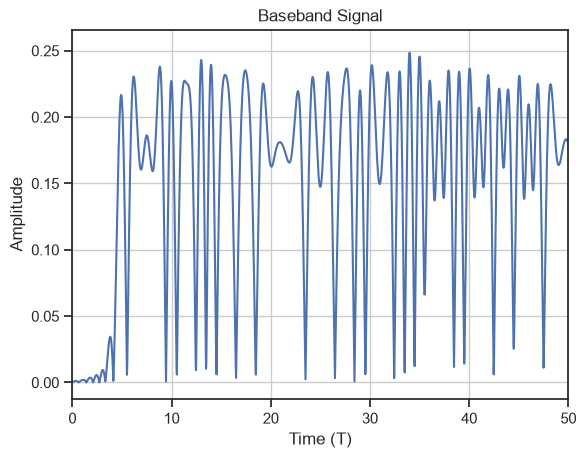

In [4]:
plt.plot(np.arange(len(bb_sig))/fsT, np.abs(bb_sig))
plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Baseband Signal')
plt.grid(True)
plt.xlim(0, 50)
plt.show()

## Simulating transmission

Our simulated transmission will include:

* AWGN
* a delay of 102 samples
* amplitude and phase change
* reduction of the sample rate from 32 to 8; note that 102 is not evenly divisible by 8 so that we incur a fractional delay
* frequency offset is not simulated at this time

In [5]:
## channel parameters
delay_samples = 102
ds_factor = 4       # down-sample by 4
fsT_r = fsT // ds_factor

# frequency offset per sample, phase change is 0.1*2*pi over course of preamble
df = 0.1/(len(preamble_symbols) * fsT) 
X = .5*np.exp(1j*np.pi/4) # amplitude and phase
#adjust
# df = 0.1/(len(preamble_symbols) * fsT) 
# X = 1.*np.exp(1j*0*np.pi/4) # amplitude and phase

# delay by pre-pending zeros
rr = np.concatenate(( np.zeros(delay_samples), 
                     X * bb_sig * np.exp(2j * np.pi * df * np.arange(len(bb_sig))), 
                     np.zeros(delay_samples) ))

# down-sample
rr = rr[::ds_factor]
fsT_r = fsT // ds_factor

SNR_dB = 40
SNR = 10**(SNR_dB/10)
noise_var = preamble_constellation.Es / SNR 

## the down-sampled signal amplitude is increased, to compensate for "energy" lost
# when discarding samples
rr = np.sqrt(ds_factor)*rr + np.sqrt(0.5 * noise_var) * (np.random.randn(len(rr)) + 1j*np.random.randn(len(rr))) 

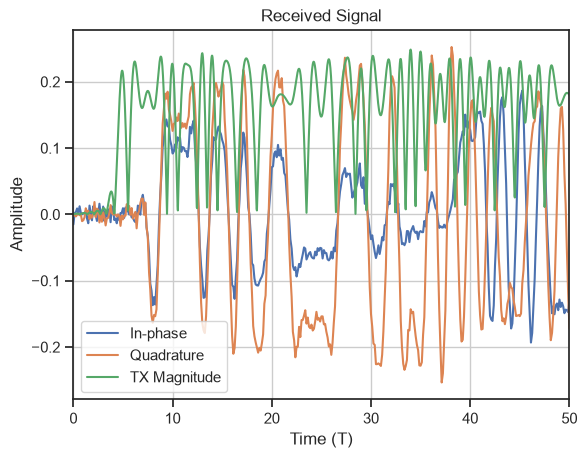

In [6]:
plt.plot(np.arange(len(rr))/fsT_r, rr.real, label="In-phase")
plt.plot(np.arange(len(rr))/fsT_r, rr.imag, label="Quadrature")
plt.plot(np.arange((len(bb_sig)))/fsT, 
         np.abs(bb_sig), label="TX Magnitude")

plt.xlabel('Time (T)')
plt.ylabel('Amplitude')
plt.title('Received Signal')
plt.xlim(0, 50)
plt.grid(True)
plt.legend(loc='lower left')
plt.show()

For reference: With the above parameters, the first sample of the preamble is the 25-th or 26-th (102/4) sample of the received signal. 

## Receiver Processing

The goal is to develop a full receiver that can accurately detect and synchronize with the preamble of the received signal, and subsequently demodulate the transmitted data. To help this goal, the `PolyPhaseCorrelator` class below computes all quantities necessary for detecting the preamble and determining the optimal sampling phase. Note that this correlator assumes that the received signal is passed through a pulse matched filter.

The remaining tasks to complete the receiver include:
- Implementing the preamble detection logic using the output of the `PolyPhaseCorrelator`. This involves replacing the peak search over the entire signal with detection using a suitably chosen threshold. This process should account for the (likely) case that the first breach of the threshold does not correspond to the peak of the correlator output; that is likely to occur a few samples after the first breach. The detection logic should output:
    + the estimated sampling phase
    + the estimated symbol index of the preamble peak
    + the correlator output at the detected preamble peak
- Estimation of additional channel parameters once the preamble has been detected, including:
    + the channel complex gain (amplitude and phase)
    + the frequency offset (be explicit, if this is estimated in Hz or as normalized frequency. For a normalized frequency, there are two options: cycles per sample or cycles per symbol)
    + the noise variance (at the matched filter output)
- Applying the estimated channel parameters to the received signal for proper synchronization. Upon detection of the preamble and estimation of the channel parameters, the receiver must correct the received signal to compensate these channel effects.
    + Note: determining the correct phase requires a little thought, as it depends on the phase of the channel complex gain, the frequency offset, and the delays introduced by channel and matched filter.
- Demodulating the received data symbols after synchronization. The correct phase of the matched filter outputs, with corrected amplitude frequency and phase, must be demodulated starting with the first symbol after the preamble.

Ultimately, all of these pieces should be integrated into a complete receiver chain; that is probably best realized as a single class. It should:
* toggle between two states:
    + preamble detection and synchronization
    + data demodulation
* at the transition from synchronization to data demodulation, the various parameter estimates should be computed
* estimates of the channel parameters (complex gain, frequency offset, noise variance) should be used to correct the received signal before demodulation
* the correct samples must be fed to the demodulator: correct first sample and correct sampling phase
* after demodulation, the receiver transitions back to the preamble detection and synchronization state for the next frame. At the transition, the correlator is reset.

**Hint:** In the received signal, the preamble starts at the 26-th sample. Probably more importantly, after the signal is passed through the matched filter, the first sample of the preamble is the 105-th sample of the matched filter output. The first sample of the data is the 353-rd sample of the matched filter output (105 + 31*8 = 353). 

You can use this information: 
* to verify the correctness of your preamble detection and synchronization logic and 
* to develop and test the estimation of the channel parameters. 
* Even the demodulation process can leverage this information to locate the start of the data symbols.

### How to use the `PolyPhaseCorrelator`

The `PolyPhaseCorrelator` is used to perform sequential polyphase correlation for signal synchronization. It processes the output of a matched filter and computes the correlation with a known preamble sequence for each sampling phase. This allows for real-time synchronization and enables transitioning to demodulation as soon as synchronization is achieved.

The correlator operates on the output of the pulse matched filter. It is fed one sample at a time, updating its internal state and computing the correlation after the insertion of each new sample.

As such the correlator should operate in a loop, continuously feeding it new matched filter output samples until the preamble is detected. At that point, parameters should be estimated and the synchronization process can transition to demodulation.

The example below demonstrates the use of the correlator for computing the cross-correlation between the matched filter output and the known preamble sequence for the entire signal, i.e., there is no detection logic or parameter estimation.

## Skeleton for a Receiver class

The following thoughts outline the design and implementation considerations for a receiver class that supports both synchronization/acquisition and demodulation:

**Note:** For this version, quadrature down-conversion (with resampling) and matched filter processing are outside the receiver. In other words, the input signal to the receiver is the output of the matched filter. This is very likely subject to change.

### Receiver contains a finite state-machine (FSM) for synchronization and demodulation

The receiver switches between two states: synchronization (`SYNCH`) and demodulation (`DEMOD`).

- In the `SYNCH` state, the receiver attempts to acquire timing and frequency synchronization with the incoming signal.
- In the `DEMOD` state, the receiver demodulates the synchronized signal to recover the transmitted data.

### Subsystems

The receiver class is composed of several subsystems that handle different aspects of the signal processing chain:

- **PolyPhaseCorrelator:** Responsible for correlating the incoming signal with the known preamble sequence across multiple sampling phases.
- **ThresholdDetector:** Detects when the correlation magnitude exceeds a predefined threshold, indicating potential synchronization.
- **Estimator:** Estimates synchronization parameters such as phase and frequency offsets based on the correlation results.
- **Slicer:** Maps the corrected demodulated samples to the nearest constellation points, effectively recovering the transmitted bits.

These subsystems maybe passed (fully configured) to the Receiver or may be instantiated by the Receiver itself.

### Return Value

The receiver's `process` method returns a dictionary containing the results of the processing, including:

- `n_phase`: The detected sampling phase corresponding to the preamble sequence.
- `corr_val`: The correlation value at the detected sampling phase.
- `phasor`: The estimated phase correction factor.
- `frequency_offset_per_symbol`: The estimated frequency offset per symbol.
- `bits`: The recovered transmitted bits after demodulation and slicing.

[DEBUG] Internal Results detect():
First time Crossing Threshold at sample_count,341,test_stat,0.513299081837096
Incrementing Samples since breach at sample_count,342,test_stat,0.7392806659624576
Better peak sample_count,342,test_stat,0.7392806659624576
Incrementing Samples since breach at sample_count,343,test_stat,0.8836996533756653
Better peak sample_count,343,test_stat,0.8836996533756653
Incrementing Samples since breach at sample_count,344,test_stat,0.9511682574692525
Better peak sample_count,344,test_stat,0.9511682574692525
Incrementing Samples since breach at sample_count,345,test_stat,0.9678844183008262
Better peak sample_count,345,test_stat,0.9678844183008262
Incrementing Samples since breach at sample_count,346,test_stat,0.9420699893259862
Incrementing Samples since breach at sample_count,347,test_stat,0.8556339433956164
Falling edge test. Locking in best peak found.

[DEBUG] Detection Results
Internal process() results at end of SYNCH mode
Peak detected at grid position: [ph

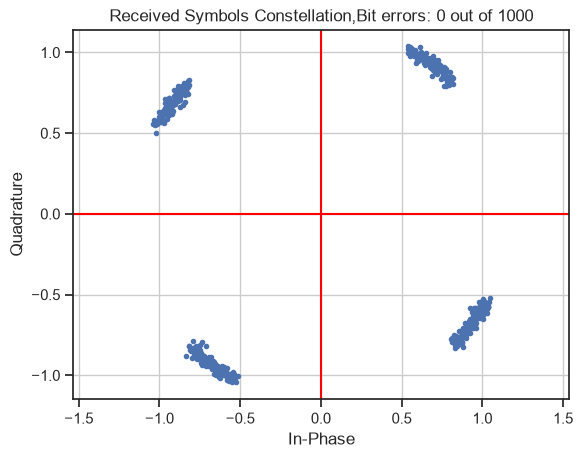

Detection Threshold,0.3,Detection UseNorm True


In [ ]:
## matched filter output
# we need a different pulse than the transmitter because the oversampling factor is different
DEBUG=True
mf_hh = SqrtRaisedCosinePulse(num_samples=10*fsT_r, oversamp=fsT_r, alpha=0.5)._generate_samples()
mf_out = np.convolve(rr, np.flipud(mf_hh.conj()))



# Suggested options
# detection_useNorm=False
# detection_threshold=215
#
detection_useNorm=True
detection_threshold=.3
rx=Receiver(preamble_seq=preamble_symbols,fsT=fsT_r,slicer=GenericSlicer(payload_constellation),detection_threshold=detection_threshold,detection_useNorm=detection_useNorm)

results=rx.process(mf_out,500)

#Check detection results
received_preamble_buffer=results['received_preamble_buffer']
p_ind=results['p_ind']
k_ind=results['k_ind']
corr_val=results['corr_val']
mode=results['detected']

if DEBUG is True:
    print("\n" + "=" * 60)
    print(f"--- Peak Correlation Results ---")
    print(f"Absolute Max Magnitude: {np.abs(corr_val):.4f}")
    print(f"Best Sampling Phase (p_ind): {p_ind}")
    print(f"Best Symbol Index (k_ind):    {k_ind}")
    print(f"Complex Value at Peak:        {corr_val}")

    print("\n")
    print("idx received sample expected error angle")
    print("idx received sample expected error angle(rad)")
    for i, (r, p) in enumerate(zip(received_preamble_buffer[:10],
        preamble_symbols[:10])):
        error = int(np.sign(r.real) != np.sign(p.real))
        angle=np.angle(r)
        print(
        f"{i:2d} "
        f"{r.real:8.4f}{r.imag:+8.4f}j "
        f"{p.real:.0f}{p.imag:+.0f}j "
        f"{error:5d}"
        f"{angle:10.2f}"
    )

    print("\n" + "=" * 60)

#Check estimation results
corrected_symbols = results['demod_samples_corrected']
#print(f"[DEBUG] len(corrected_symbols),{len(corrected_symbols)}")

#Slicer 
N_bits=len(payload_bits)
rx_bits= results['bits']
BER=np.sum(payload_bits != rx_bits)/N_bits

if DEBUG is True:
    print(f"bit errors: {np.sum(payload_bits != rx_bits)} out of {N_bits}")

plt.plot(np.real(corrected_symbols), np.imag(corrected_symbols), '.b')
#plt.plot(np.real(corrected_symbols[:20]), np.imag(corrected_symbols[:20]), '.b')
plt.xlabel('In-Phase')
plt.ylabel('Quadrature')
plt.title(f"Received Symbols Constellation,Bit errors: {np.sum(payload_bits != rx_bits)} out of {N_bits}")
plt.grid(True)
plt.axis('equal')
# plt.xlim(-1.5,1.5)
# plt.ylim(-1.5,1.5)
plt.axhline(0, color='red', linewidth=1.5)
plt.axvline(0, color='red', linewidth=1.5)    
plt.show()


print(f"Detection Threshold,{detection_threshold},Detection UseNorm {detection_useNorm}")
#print(f"First bit errors: {np.sum(payload_bits[:20] != rx_bits[:20])} out of {20}")
#print(f"Phasor,{results['phasor']}")


